In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix

In [2]:
df = pd.read_csv('website_ab_test.csv')

<h2>Preprocessing</h2>

In [22]:
df.isna().sum()

Theme                 0
Click Through Rate    0
Conversion Rate       0
Bounce Rate           0
Scroll_Depth          0
Age                   0
Location              0
Session_Duration      0
Purchases             0
Added_to_Cart         0
dtype: int64

In [23]:
df.describe()

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Age,Session_Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.256048,0.253312,0.505758,50.319494,41.528000,924.999000
std,0.139265,0.139092,0.172195,16.895269,14.114334,508.231723
min,0.010767,0.010881,0.200720,20.011738,18.000000,38.000000
25%,0.140794,0.131564,0.353609,35.655167,29.000000,466.500000
50%,0.253715,0.252823,0.514049,51.130712,42.000000,931.000000
75%,0.370674,0.373040,0.648557,64.666258,54.000000,1375.250000
max,0.499989,0.498916,0.799658,79.997108,65.000000,1797.000000


<p>There are non null values, and the data description indicates that outliers are rare or non existant. This is supported by the fact that the max values are all roughly within 2 standard deviations of the mean. Therefore, no further data preprocessing needs to be done </p>

<h2>Analyzing By Age</h2>

In [3]:
age_df = df.copy(deep=True)

In [4]:
bins = [18,28,48,65]
labels_list = ['18 to 25 year olds', '28 to 48 year olds','48 to 65 year olds']

In [5]:
age_df.Age = pd.cut(age_df.Age, bins, labels = labels_list)

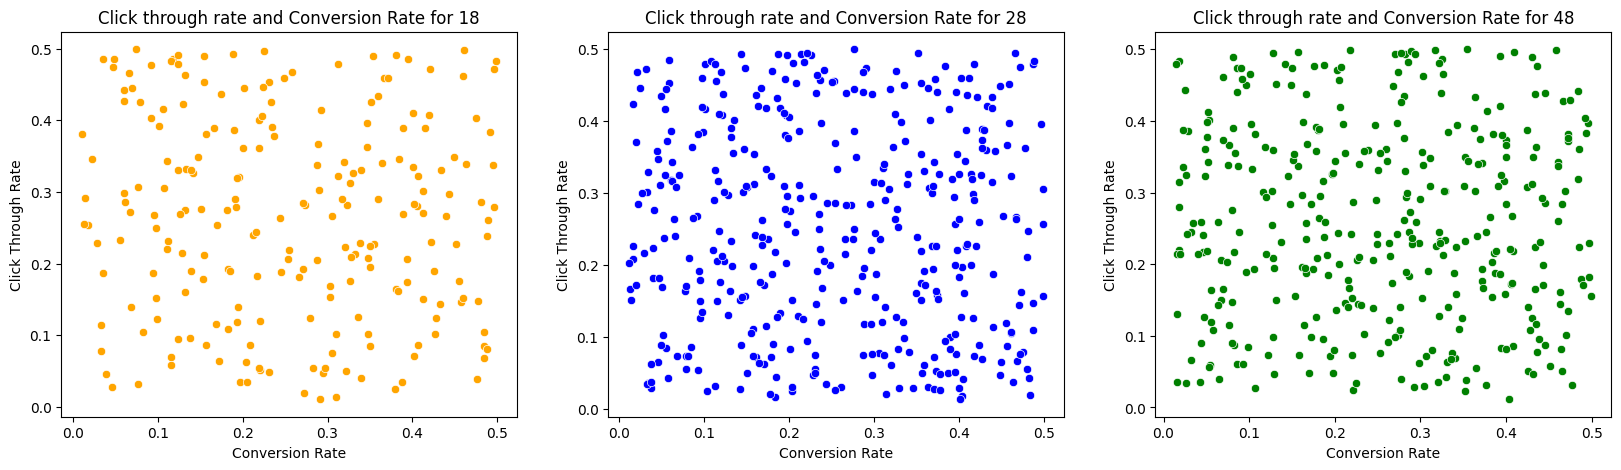

In [6]:
fig, axes = plt.subplots(1,3, figsize=(20,5))
colors = ['orange','blue','green']
for count ,label in enumerate(labels_list):
    sns.scatterplot(age_df[age_df.Age==label], x='Conversion Rate', y='Click Through Rate', ax=axes[count],color=colors[count]).set_title(f'Click through rate and Conversion Rate for {bins[count]}')

In [7]:
age_df[age_df.Age==labels_list[2]].iloc[:,0:5].describe(),age_df[age_df.Age==labels_list[2]].iloc[:,0:5].describe(),age_df[age_df.Age==labels_list[2]].iloc[:,0:5].describe()

(       Click Through Rate  Conversion Rate  Bounce Rate  Scroll_Depth
 count          360.000000       360.000000   360.000000    360.000000
 mean             0.258135         0.253482     0.517032     50.447873
 std              0.135382         0.139293     0.177920     17.042362
 min              0.011478         0.014701     0.201318     20.328167
 25%              0.149191         0.131384     0.368511     35.967484
 50%              0.244355         0.262783     0.529628     50.396993
 75%              0.364070         0.371488     0.668705     65.021225
 max              0.499989         0.498609     0.799658     79.760824,
        Click Through Rate  Conversion Rate  Bounce Rate  Scroll_Depth
 count          360.000000       360.000000   360.000000    360.000000
 mean             0.258135         0.253482     0.517032     50.447873
 std              0.135382         0.139293     0.177920     17.042362
 min              0.011478         0.014701     0.201318     20.328167
 25% 

<hr>
<p>Similiar statistics across age groups indicate that the demographic of age has no significant impact on factors such as click through rate, depth of scroll, and conversion rate. This means that age is not a significant factor to consider when changing the website, as it is currently equally catering to all age groups</p>
<hr>

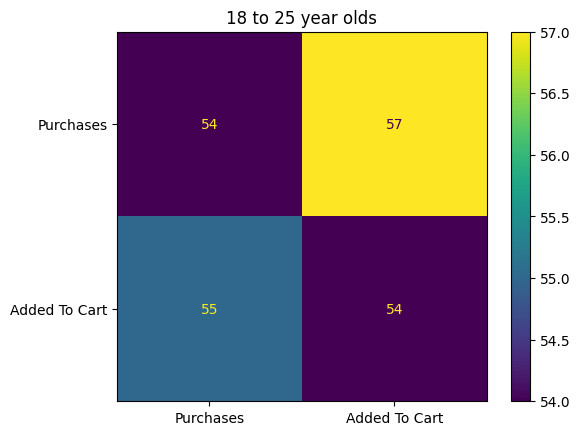

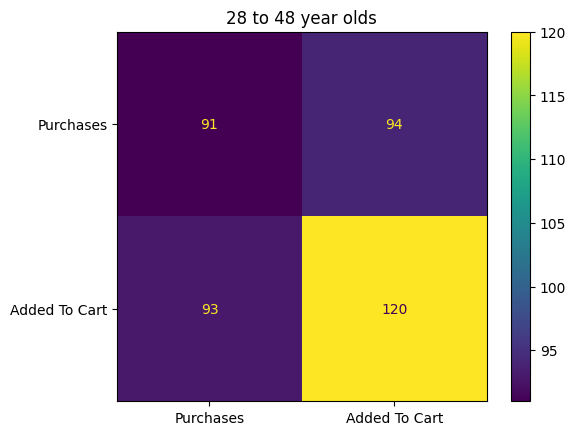

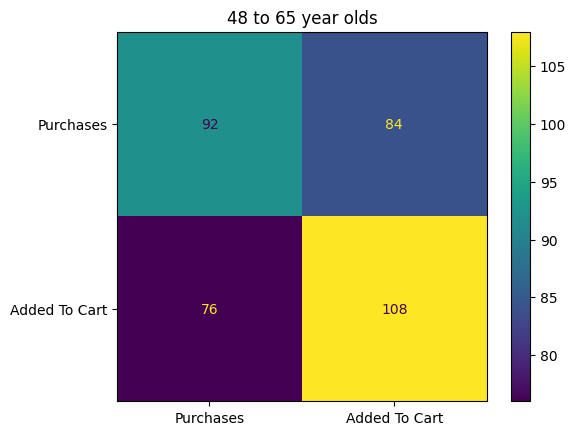

In [8]:
for count, label in enumerate(labels_list):
    per_age_cat_df = age_df[age_df['Age'] == label]
    matrix = ConfusionMatrixDisplay(confusion_matrix(per_age_cat_df['Purchases'], per_age_cat_df['Added_to_Cart']), display_labels=['Purchases','Added To Cart']).plot()
    matrix.ax_.set_xlabel('')
    matrix.ax_.set_ylabel('')

    plt.title(label)

<p>However, it can also be seen from the matrixes that while there seems to be no relationship
between Adding to cart and purchasing in the youngest age group, the older age groups show a larger porportion of people who both add to cart and purchase the product, instead of doing one or the other. This indicates that it is more worthwhile to follow up people of older age groups that have unfinished carts (through email or promotional media) as it is likely to yield a better chance of purchase</p>
<hr>

<h5>Further Analysis</h5>

In [9]:
age_df[age_df['Age']==labels_list[0]]['Purchases'].value_counts()

Purchases
No     111
Yes    109
Name: count, dtype: int64

In [10]:
age_df[age_df['Age']==labels_list[1]]['Purchases'].value_counts()

Purchases
Yes    213
No     185
Name: count, dtype: int64

In [11]:
age_df[age_df['Age']==labels_list[2]]['Purchases'].value_counts()

Purchases
Yes    184
No     176
Name: count, dtype: int64

In [12]:
age_df[age_df['Age']==labels_list[0]]['Session_Duration'].describe()

count     220.000000
mean      908.318182
std       494.389831
min        40.000000
25%       463.500000
50%       922.000000
75%      1313.750000
max      1797.000000
Name: Session_Duration, dtype: float64

In [13]:
age_df[age_df['Age']==labels_list[1]]['Session_Duration'].describe()

count     398.000000
mean      926.226131
std       510.112631
min        40.000000
25%       462.750000
50%       934.500000
75%      1398.750000
max      1797.000000
Name: Session_Duration, dtype: float64

In [14]:
age_df[age_df['Age']==labels_list[2]]['Session_Duration'].describe()

count     360.000000
mean      934.444444
std       522.332680
min        38.000000
25%       466.250000
50%       925.500000
75%      1399.000000
max      1795.000000
Name: Session_Duration, dtype: float64

<hr>
There is no significant effect on age on session duration and purchases
<hr>

<h2>Analyzing By Theme</h2>

<p> Testing Hypothesis that the theme will have a significant effect on user actions and/or has strong correlations with their demographics</p>

In [15]:
theme_df = df.copy(deep=True)

In [16]:
theme_continous = pd.concat([theme_df.iloc[:,0:5],theme_df['Session_Duration']], axis=1)

In [17]:
theme_continous.groupby('Theme').mean()

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Session_Duration
Theme,,,,,
Dark Theme,0.264501,0.251282,0.512115,49.926404,919.482490
Light Theme,0.247109,0.255459,0.499035,50.735232,930.833333


In [18]:
theme_categorical = theme_df.select_dtypes('object').drop('Location', axis=1)

In [19]:
theme_categorical.groupby('Theme').value_counts()

Theme        Purchases  Added_to_Cart
Dark Theme   Yes        Yes              142
             No         No               130
                        Yes              125
             Yes        No               117
Light Theme  Yes        Yes              146
             No         No               115
                        Yes              113
             Yes        No               112
Name: count, dtype: int64

<p>The above code ran a description of the values of individual columns when grouped by theme. As can be seen, there are no significant differences when comparing the means for light and dark theme across multiple features. It doesn't seem to have an effect on categorical data such as whether purchases were made or were added to cart, as values don't seem to differ significantly amongst them. Overall, it can be said that dark or light themes have little to no significant effect on user activity</p>

In [20]:
df

,Theme,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Age,Location,Session_Duration,Purchases,Added_to_Cart
0,Light Theme,0.054920,0.282367,0.405085,72.489458,25,Chennai,1535,No,Yes
1,Light Theme,0.113932,0.032973,0.732759,61.858568,19,Pune,303,No,Yes
2,Dark Theme,0.323352,0.178763,0.296543,45.737376,47,Chennai,563,Yes,Yes
3,Light Theme,0.485836,0.325225,0.245001,76.305298,58,Pune,385,Yes,No
4,Light Theme,0.034783,0.196766,0.765100,48.927407,25,New Delhi,1437,No,No
...,...,...,...,...,...,...,...,...,...,...
995,Dark Theme,0.282792,0.401605,0.200720,68.478822,25,Kolkata,321,Yes,Yes
996,Dark Theme,0.299917,0.026372,0.762641,73.019821,38,Chennai,1635,Yes,Yes
997,Light Theme,0.370254,0.019838,0.607136,33.963298,32,Bangalore,1237,No,Yes
998,Light Theme,0.095815,0.137953,0.458898,37.429284,24,Chennai,893,Yes,No
